# Makine Öğrenmesi

Makine öğrenmesi veriden örüntüler (pattern) çıkarma temeline dayanır. Bu derste de verideki örüntüleri çıkarmak için kullanılan temel kavramları göreceğiz. Bu kavramları bilmek veriyi analiz etmek için şart olmasa da analizlerde çıkabilecek problemlerin neden olabileceği ve nasıl çözülebileceği hakkında ipucu verebilir.

Öncelikle kullanacağımız paketleri yüklüyoruz.

In [14]:
%matplotlib inline
from ipywidgets import interactive
#Grafik çizdirme
import matplotlib.pyplot as plt
#Güzel grafik çizdirme
import seaborn as sns
#Numerik işlemler
import numpy as np
#Veri çerçeveleri için
import pandas as pd
#Kullanacağımız veri setleri için
from sklearn import datasets

İlk olarak diabetes veri setini okutacağız ve ilk 20 gözlemi çizdireceğiz. Bunun için X değişkeninin 3. kolonunu (2 numaralı indeks) kullanacağız.

In [15]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y = True)
print('diabetes_X boyutlar: ' + str(np.shape(diabetes_X)))
print('diabetes_y boyutlar: ' + str(np.shape(diabetes_y)))

diabetes_X = diabetes_X[:20]
diabetes_y = diabetes_y[:20]

diabetes_X boyutlar: (442, 10)
diabetes_y boyutlar: (442,)


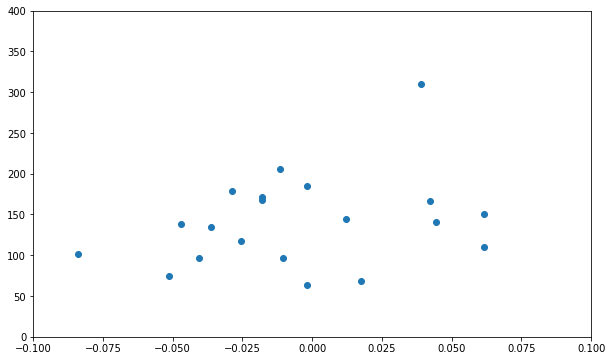

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(diabetes_X[:,2], diabetes_y)
plt.xlim((-0.1,0.1))
plt.ylim((0,400))
plt.show()

`x` değişkeni arttıkça `y` değişkeni de artıyor gibi duruyor.

$y = 150 + 750 x$ doğrusunu çizdirerek veriyi öğrenmeye başlayalım.

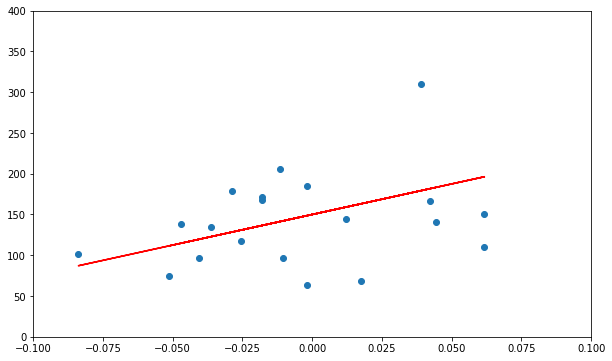

In [17]:
intercept = 150
slope = 750
y_pred = slope * diabetes_X[:,2] + intercept
plt.figure(figsize=(10,6))
plt.scatter(diabetes_X[:,2], diabetes_y)
plt.plot(diabetes_X[:,2], y_pred, c='red')
plt.xlim((-0.1,0.1))
plt.ylim((0,400))
plt.show()

Eğimi biraz arttırırsak daha iyi sonuç alabilir miyiz?

$y = 150 + 1100 x$ doğrusunu çizdirelim.

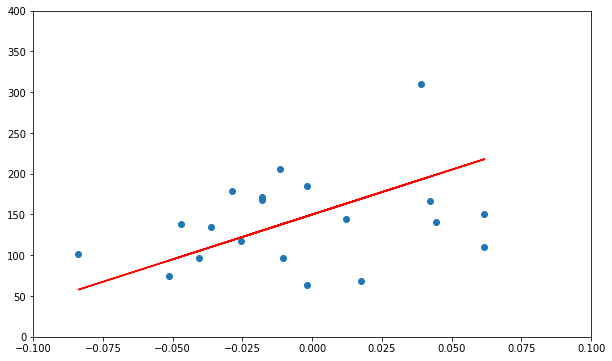

In [18]:
intercept = 150
slope = 1100
y_pred = slope * diabetes_X[:,2] + intercept
plt.figure(figsize=(10,6))
plt.scatter(diabetes_X[:,2], diabetes_y)
plt.plot(diabetes_X[:,2], y_pred, c='red')
plt.xlim((-0.1,0.1))
plt.ylim((0,400))
plt.show()

Daha iyi bir örüntü elde edip edemediğimizi anlamak için objektif bir değerlendirmeye ihtiyacımız var. Bu amaçla gözlemler ve çizdirdiğimiz doğru arasındaki uzaklığı kullanabiliriz. 

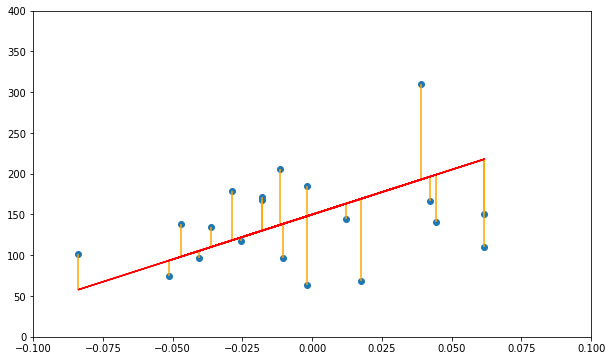

In [19]:
intercept = 150
slope = 1100
y_pred = slope * diabetes_X[:,2] + intercept
plt.figure(figsize=(10,6))
plt.scatter(diabetes_X[:,2], diabetes_y)
plt.plot(diabetes_X[:,2], y_pred, c='red')
plt.xlim((-0.1,0.1))
plt.ylim((0,400))

for i in range(len(diabetes_X[:,2])):
    x = diabetes_X[i,2]
    y = intercept + slope * x
    plt.vlines(x, y, diabetes_y[i], color = 'orange')
plt.show()

Değerlendirme ölçütü olarak genelde uzaklığın karelerinin ortalaması bulunur ve bunun karekökü alınır. Başka metrikler de mümkün olmasına rağmen biz de RMSE (Root Mean Squared Error) değerini kullanalım.

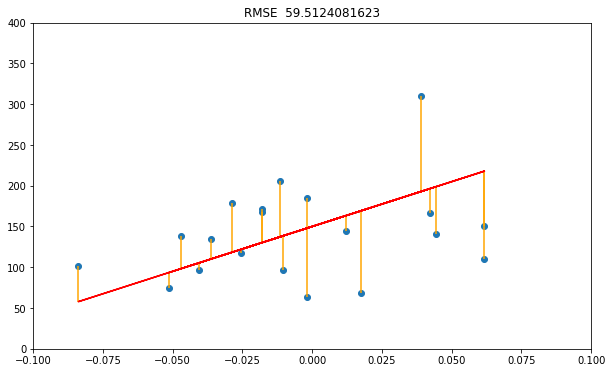

In [20]:
intercept = 150
slope = 1100
y_pred = slope * diabetes_X[:,2] + intercept
plt.figure(figsize=(10,6))
plt.scatter(diabetes_X[:,2], diabetes_y)
plt.plot(diabetes_X[:,2], y_pred, c='red')
plt.xlim((-0.1,0.1))
plt.ylim((0,400))

for i in range(len(diabetes_X[:,2])):
    x = diabetes_X[i,2]
    y = intercept + slope * x
    plt.vlines(x, y, diabetes_y[i], color = 'orange')
plt.title('RMSE  ' + str(np.sqrt(((diabetes_y - (slope * diabetes_X[:,2] + intercept)) ** 2).mean())))
plt.show()

Artık hedefimiz belli. RMSE değerini enküçüklemek istiyoruz. Bunu yapmak için de eğim ve kesişim noktalarını değiştirebiliriz.

In [21]:
scatter_x = diabetes_X[:,2]
scatter_y = diabetes_y

def f(Slope, Intercept):
    plt.figure(figsize=(10,6))
    x = np.linspace(-0.15, 0.15, num=1000)
    plt.scatter(scatter_x,scatter_y)
    plt.plot(x, Slope * x + Intercept)
    plt.hlines(Intercept, -0.2, 0.2, lw=2, color='r', label='Intercept')
    for i in range(len(scatter_x)):
        x1 = scatter_x[i]
        y = Intercept + Slope * x1
        plt.vlines(x1, y, diabetes_y[i], color = 'orange')

    plt.title('RMSE  ' + str(np.sqrt(((scatter_y - (Slope * scatter_x + Intercept)) ** 2).mean())))
    plt.ylim((0,400))
    plt.xlim((-0.1,0.1))
    plt.legend()
    plt.show()


interactive_plot = interactive(f, Slope=(-600, 600,10), Intercept=(50, 200, 5))
output = interactive_plot.children[-1]

interactive_plot

A Jupyter Widget

Şimdi manuel olarak yaptığımızı `scikit-learn` paketiyle yapmayı deneyelim. `scikit-learn` paketi makine öğrenmesindeki temel yöntemleri içeren bir kütüphanedir. `fit`, `predict` API'ı sayesinde oldukça kolay analiz yapılabilir.

In [22]:
#Lineer regresyon modelini ve hata metriklerini yüklüyoruz.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, log_loss

#Model oluşturalım. Modelin interept değerini de içermesini istediğimizi belirtelim.
lr = LinearRegression(fit_intercept=True)
#Modeli eğitelim
lr.fit(diabetes_X[:,2].reshape(-1,1), diabetes_y)

#
print('Slope: ' + str(lr.coef_))
print('Intercept: ' + str(lr.intercept_))
print('Hata: ' + str(np.sqrt(mean_squared_error(diabetes_y, lr.predict(diabetes_X[:,2].reshape(-1,1))))))

Slope: [ 407.75511977]
Intercept: 143.181155333
Hata: 52.9837585833


Oldukça yakın değerler elde ettik.

Burada yaptıklarımız çoğu makine öğrenmesi algoritmasının temelinde yatan kavramlar. 
* Bunlardan ilki türev hesaplayarak gideceğimiz yönü belirlemek.
* İkincisi ise o türevin tersi yönde ne kadar gideceğimizi belirlemek.

# Sınıflandırma

Benzer bir yapı sınıflandırma problemlerinde de vardır. burada da amaç sınıflandırmada yapılan hatayı azaltmak. Aşağıdaki veri setinde öğrencilerin çalıştığı saat ve sınavı geçip geçememe durumunu içeren bir veri seti var. Veri setini okuyup inceleyelim.

   Hours  Pass
0   0.50     0
1   0.75     0
2   1.00     0
3   1.25     0
4   1.50     0
   Hours  Pass  Intercept
0   0.50     0          1
1   0.75     0          1
2   1.00     0          1
3   1.25     0          1
4   1.50     0          1


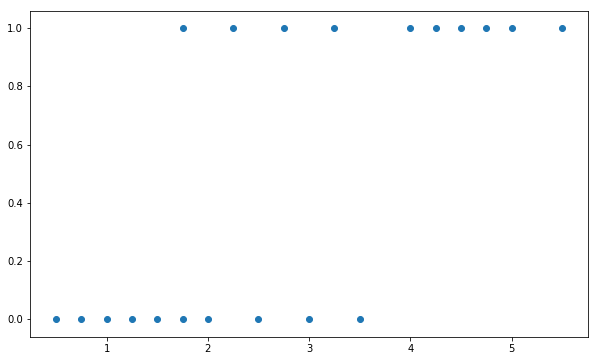

In [23]:
df = pd.read_csv('Grades.csv')
print(df.head())
#Kesişim noktası için 1 değerinden oluşan bir kolon ekleyelim 
df['Intercept'] = 1
print(df.head())
plt.figure(figsize=(10,6))
plt.scatter(df.Hours, df.Pass)
plt.show()

Gördüğümüz gibi az çalışan öğrencilerin sınavı geçme olasılığı daha düşük. Şimdi bunu lojistik regresyon modeli ile öğrenmeye çalışalım. Hata olarak `log_loss` değerini kullanacağız.

In [24]:
%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

scatter_x = df.Hours
scatter_y = df.Pass

def f(w, b):
    x = np.linspace(-1, 6, num=1000)
    plt.figure(figsize=(10,6))
    plt.scatter(scatter_x,scatter_y)
    y_pred = 1 / (1 + np.exp(-(w*scatter_x - b)))
    plt.plot(x, (1 / (1 + np.exp(-(w*x - b)))))
    plt.vlines((b/w), -0.5, 1.5, lw=2, color='r')
    plt.title('Log-loss  ' + str(log_loss(scatter_y, y_pred)))
    plt.ylim(-0.5, 1.5)
    plt.show()


interactive_plot = interactive(f, w=(-2, 4.5, 0.1), b = (0.0, 3.0, 0.05), scatter_x = scatter_x, scatter_y = scatter_y)
output = interactive_plot.children[-1]
#output.layout.height = '350px'
interactive_plot

A Jupyter Widget

In [25]:
#Lojistik regresyon fonksiyonunu yükleyelim
from sklearn.linear_model import LogisticRegression

#Modeli oluşturalım
logr = LogisticRegression(fit_intercept=True)
logr.fit(scatter_x.values.reshape(-1,1), scatter_y)

print('Katsayısı: ' + str(logr.coef_))
print('Intercept: ' + str(-logr.intercept_))
print('Hata (log_loss): ' + str(log_loss(scatter_y, logr.predict_proba(scatter_x.values.reshape(-1,1))[:,1])))

Katsayısı: [[ 0.61126347]]
Intercept: [ 1.36550178]
Hata (log_loss): 0.489980678791


Aynı sınıflandırmayı bir de karar ağaçlarıyla yapalım ve karar sınırlarını görelim.

In [26]:
#Karar ağacı fonksiyonunu yükleyelim
from sklearn.tree import DecisionTreeClassifier
#Modeli oluşturup eğitelim.
dt = DecisionTreeClassifier()
dt.fit(scatter_x.values.reshape(-1,1), scatter_y)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

C:\Users\byuceoglu\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: object of type <class 'float'> cannot be safely interpreted as an integer.
  """Entry point for launching an IPython kernel.


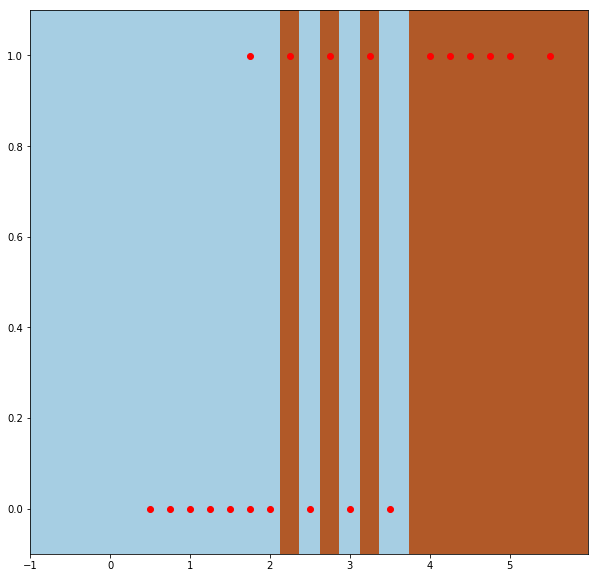

In [27]:
x = np.linspace(-1,6,0.01)
y=[-0.1,0.5,1.1]

plot_step = 0.02

xx, yy = np.meshgrid(np.arange(-1, 6, plot_step),
                         np.arange(-0.1, 1.1, plot_step))

decision_data = np.c_[xx.ravel(), yy.ravel()]
Z = dt.predict(decision_data[:,0].reshape(-1,1))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,10))
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Paired,
           aspect='auto', origin='lower')
plt.scatter(scatter_x,scatter_y, c='red')
plt.ylim(-0.1, 1.1)
plt.axis("tight")
plt.show()

Bir hata ile veriyi öğrendik, ancak örüntüleri öğrenebildik mi? (Overfitting)